In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path('.')

# ── Collect results from every method folder ──────────────────────────────
folders = sorted(BASE.glob('cf-final-multiscale-*'))

metrics  = {}   # method → dict of scalar metrics
residuals = {}  # method → array of log_residuals

for folder in folders:
    method = folder.name.replace('cf-final-multiscale-', '')

    with open(folder / 'kfold_metrics.json') as f:
        metrics[method] = json.load(f)

    df = pd.read_csv(folder / 'kfold_predictions.csv')
    residuals[method] = df['log_residual'].values

methods = list(metrics.keys())
print('Methods:', methods)

Methods: ['cross_sector', 'latent_max', 'latent_mean', 'latent_mean_std', 'latent_median', 'predict_mean']


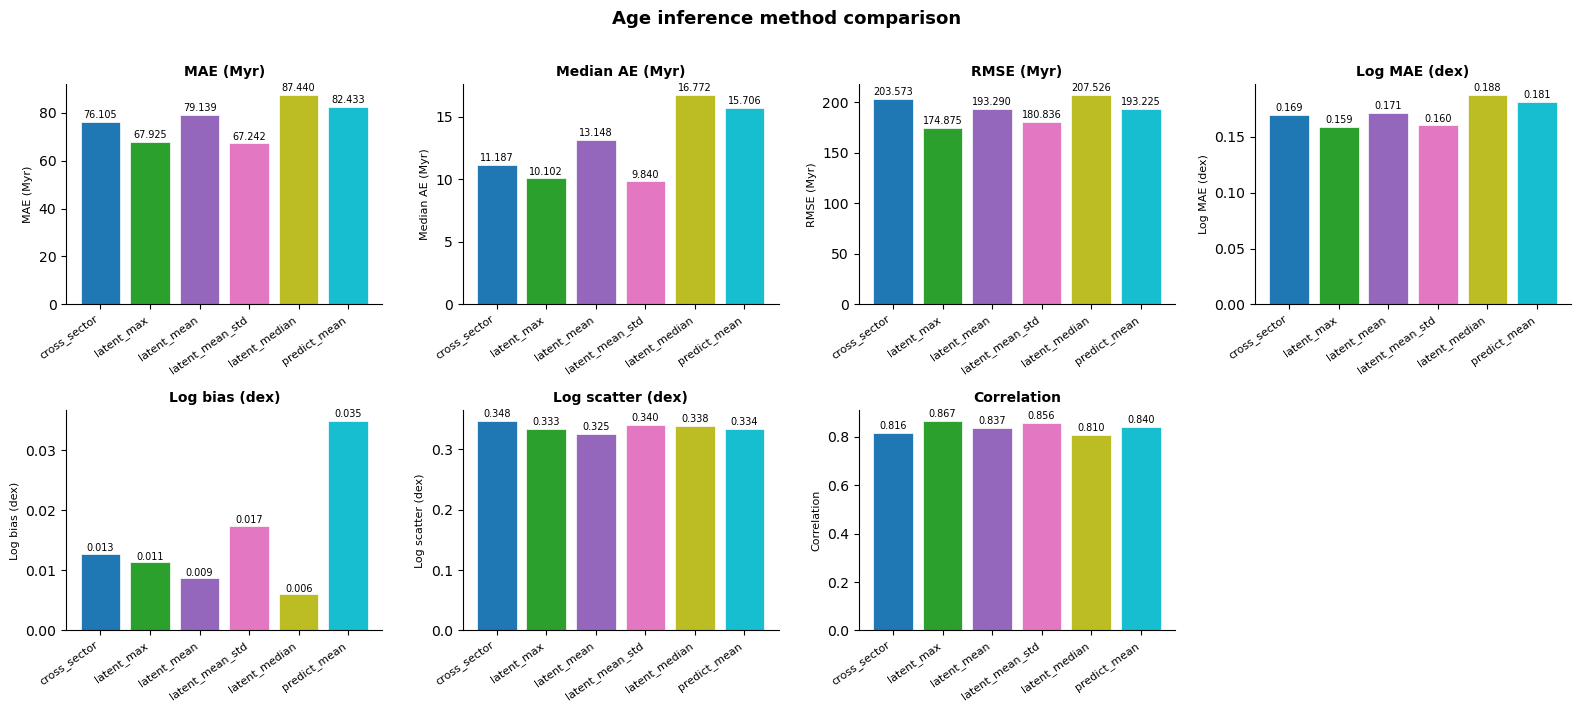

In [2]:
# ── Plot 1: per-metric comparison bar charts ──────────────────────────────
metric_keys = [
    ('mae_myr',          'MAE (Myr)'),
    ('median_ae_myr',    'Median AE (Myr)'),
    ('rmse_myr',         'RMSE (Myr)'),
    ('log_mae_dex',      'Log MAE (dex)'),
    ('log_bias_dex',     'Log bias (dex)'),
    ('log_scatter_dex',  'Log scatter (dex)'),
    ('correlation',      'Correlation'),
]

n_metrics = len(metric_keys)
ncols = 4
nrows = int(np.ceil(n_metrics / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()

colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
x = np.arange(len(methods))

for ax, (key, label) in zip(axes, metric_keys):
    vals = [metrics[m][key] for m in methods]
    bars = ax.bar(x, vals, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel(label, fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    # Annotate bars with values
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7
        )

# Hide unused axes
for ax in axes[n_metrics:]:
    ax.set_visible(False)

fig.suptitle('Age inference method comparison', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(BASE / 'comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

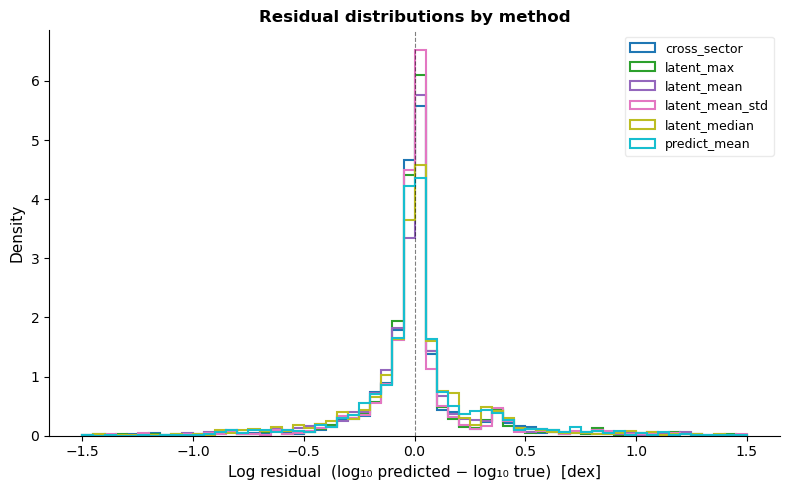

In [3]:
# ── Plot 2: overlapping residual distributions ────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(-1.5, 1.5, 61)

for (method, color) in zip(methods, colors):
    ax.hist(
        residuals[method],
        bins=bins,
        histtype='step',
        linewidth=1.5,
        color=color,
        label=method,
        density=True,
    )

ax.axvline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Log residual  (log₁₀ predicted − log₁₀ true)  [dex]', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Residual distributions by method', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
fig.savefig(BASE / 'comparison_residuals.png', dpi=150, bbox_inches='tight')
plt.show()